# Using the Met Office Site Archive

In [17]:
# Import the PyEarthTools data and pipeline modules
import pyearthtools
from pyearthtools import data, pipeline


In [2]:
# Currently needing to import py pointing the path to the site archive. 
# TODO: Investigate how to include this, or internally install the package. 
import sys
sys.path.append("/home/users/john.pill/Projects/PyEarthTools/packages/met_office_site_archive/src/")

In [3]:
# Import the met office site archive module
import site_archive_met_office

In [4]:
# Some parameters for the notebook
vmin = 220
vmax = 320

## Working with ERA5 low resolution (WeatherBench) data
This technique can be used to quickly create a dataset object. <br>
Pass an array of the variables you wish to work with to the dataset archive.

In [19]:
era5 = pyearthtools.data.archive.ERA5lowres(['2m_temperature', 'u', 'v'])
era5

ERA5lowres
	Description                    ECWMF ReAnalysis v5
		 range                          '1970-current'
		 Documentation                  'https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [ ]:
# Index on a date of interest
doi = '2015-01-01T00'  
era5_data = era5[doi]
era5_data

<xarray.Dataset> Size: 222kB
Dimensions:    (latitude: 32, longitude: 64, time: 1, level: 13)
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * time       (time) datetime64[ns] 8B 2015-01-01
  * level      (level) int32 52B 50 100 150 200 250 300 ... 600 700 850 925 1000
Data variables:
    t2m        (time, latitude, longitude) float32 8kB dask.array<chunksize=(1, 32, 64), meta=np.ndarray>
    u          (time, level, latitude, longitude) float32 106kB dask.array<chunksize=(1, 8, 19, 39), meta=np.ndarray>
    v          (time, level, latitude, longitude) float32 106kB dask.array<chunksize=(1, 8, 19, 39), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6

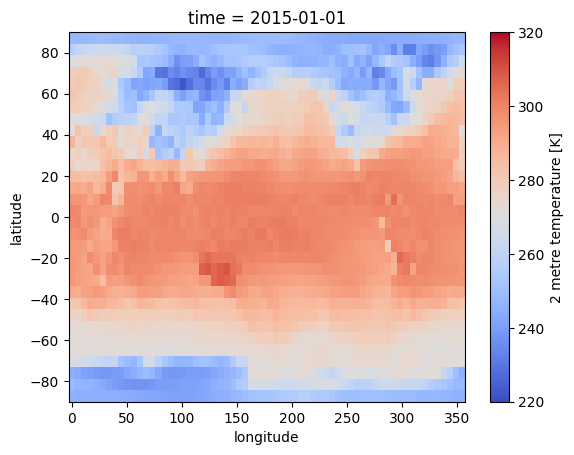

In [64]:
era5_data.t2m.plot(cmap='coolwarm', vmin=vmin, vmax=vmax)

## Working with Met Office UKV data

In [6]:
# Create Met Office Global dataset object with the desired variables. 
moukv = pyearthtools.data.archive.MOUKV(['2m_temperature', 'u', 'v'])
moukv

MOUKV
	Description                    Met Office UKV (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/ukv_model_data_sheet_2019.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [13]:
# Index on the dataset object a date of interest 
doi = '2018-01-01T03'
moukv_data = moukv[doi]
moukv_data

Matching files: [PosixPath('/data/scratch/john.pill/PET_MO_UKV_data/netcdf_files/prods_op_ukv_20180101_03_000.nc')]


<xarray.Dataset> Size: 113MB
Dimensions:                      (time: 1, grid_latitude: 810,
                                  grid_longitude: 621, pressure: 10,
                                  grid_latitude_0: 811, grid_longitude_0: 621)
Coordinates:
  * grid_latitude                (grid_latitude) float32 3kB -3.771 ... 7.151
  * grid_longitude               (grid_longitude) float64 5kB 354.9 ... 363.3
    forecast_period              timedelta64[ns] 8B ...
    forecast_reference_time      datetime64[ns] 8B ...
  * time                         (time) datetime64[ns] 8B 2018-01-01T03:00:00
    height                       float64 8B ...
  * pressure                     (pressure) float32 40B 100.0 150.0 ... 1e+03
    forecast_period_0            timedelta64[ns] 8B ...
    time_0                       datetime64[ns] 8B ...
  * grid_latitude_0              (grid_latitude_0) float32 3kB -3.777 ... 7.158
  * grid_longitude_0             (grid_longitude_0) float64 5kB 354.9 ... 363.3
    height_0                     float64 8B ...
Data variables:
    air_pressure_at_sea_level    (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    rotated_latitude_longitude   (time) int32 4B -2147483647
    air_temperature              (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    air_temperature_0            (time, pressure, grid_latitude, grid_longitude) float32 20MB dask.array<chunksize=(1, 10, 810, 621), meta=np.ndarray>
    geopotential_height          (time, pressure, grid_latitude, grid_longitude) float32 20MB dask.array<chunksize=(1, 10, 810, 621), meta=np.ndarray>
    relative_humidity            (time, pressure, grid_latitude, grid_longitude) float32 20MB dask.array<chunksize=(1, 10, 810, 621), meta=np.ndarray>
    surface_altitude             (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    toa_outgoing_shortwave_flux  (time, grid_latitude, grid_longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    x_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
    x_wind_0                     (time, pressure, grid_latitude_0, grid_longitude_0) float32 20MB dask.array<chunksize=(1, 10, 811, 621), meta=np.ndarray>
    y_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
    y_wind_0                     (time, pressure, grid_latitude_0, grid_longitude_0) float32 20MB dask.array<chunksize=(1, 10, 811, 621), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.6
    Conventions:  CF-1.7

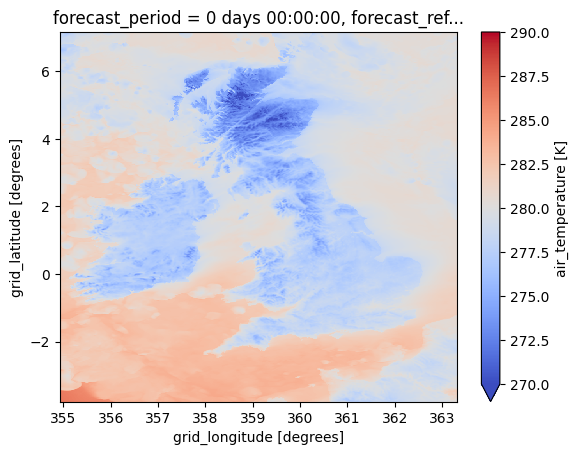

In [57]:
# Demonstrate the data by plotting in a graph. 
moukv_data.air_temperature.plot(cmap='coolwarm', vmin=270, vmax=290)

## Working with Met Office Global data

In [8]:
# Create Met Office Global dataset object with the desired variables. 
moglobal = pyearthtools.data.archive.MOGLOBAL(['2m_temperature', 'u', 'v'])
moglobal

MOGLOBAL
	Description                    Met Office Global (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/global-nwp-asdi-datasheet.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [9]:
# Index on the dataset object a date of interest. 
doi = '2018-01-01T00'
moglobal_data = moglobal[doi]
moglobal_data

Matching files: [PosixPath('/data/scratch/john.pill/PET_MO_Global_data/netcdf_files/prods_op_gl-mn_20180101_00_000.calc.nc')]


<xarray.Dataset> Size: 2GB
Dimensions:                    (time: 1, latitude: 1920, longitude: 2560,
                                bnds: 2, pressure: 13, latitude_0: 1921,
                                longitude_0: 2560)
Coordinates:
  * latitude                   (latitude) float32 8kB -89.95 -89.86 ... 89.95
  * longitude                  (longitude) float32 10kB 0.07031 0.2109 ... 359.9
    forecast_period            timedelta64[ns] 8B ...
    forecast_reference_time    datetime64[ns] 8B ...
  * time                       (time) datetime64[ns] 8B 2018-01-01
    height                     float64 8B ...
    forecast_period_0          timedelta64[ns] 8B ...
    time_0                     datetime64[ns] 8B ...
  * pressure                   (pressure) float32 52B 50.0 100.0 ... 925.0 1e+03
  * latitude_0                 (latitude_0) float32 8kB -90.0 -89.91 ... 90.0
  * longitude_0                (longitude_0) float32 10kB 0.0 0.1406 ... 359.9
    height_0                   float64 8B ...
Dimensions without coordinates: bnds
Data variables: (12/17)
    air_pressure_at_sea_level  (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    latitude_longitude         (time) int32 4B -2147483647
    air_temperature            (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    air_temperature_0          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    forecast_period_0_bnds     (time, bnds) float64 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_0_bnds                (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    ...                         ...
    relative_humidity_0        (time, pressure, latitude, longitude) float32 256MB dask.array<chunksize=(1, 10, 1585, 2114), meta=np.ndarray>
    surface_altitude           (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    x_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
    x_wind_0                   (time, pressure, latitude_0, longitude_0) float32 256MB dask.array<chunksize=(1, 10, 1586, 2113), meta=np.ndarray>
    y_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
    y_wind_0                   (time, pressure, latitude_0, longitude_0) float32 256MB dask.array<chunksize=(1, 10, 1586, 2113), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.6
    Conventions:  CF-1.7

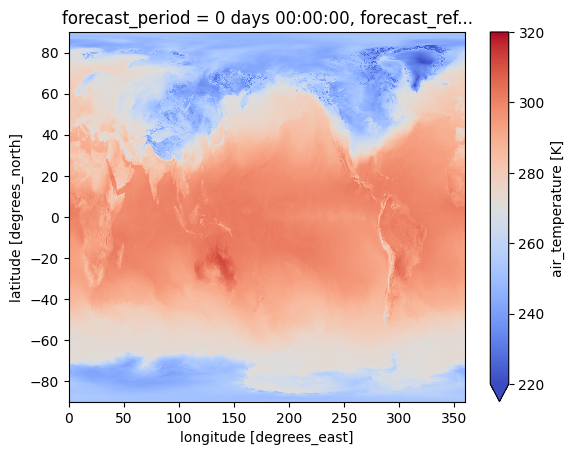

In [10]:
# Demonstrate the data by plotting in a graph. 
moglobal_data.air_temperature.plot(cmap='coolwarm', vmin=vmin, vmax=vmax)

Fontconfig error: Cannot load default config file: No such file: (null)


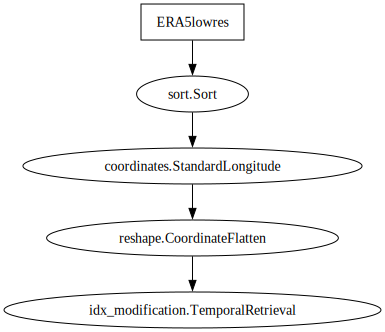

In [ ]:
data_preparation = pyearthtools.pipeline.Pipeline(
    
    pyearthtools.data.archive.ERA5lowres(["2m_temperature", "u", "v", "geopotential", "vorticity"]),    # Select data
    pyearthtools.pipeline.operations.xarray.Sort(["t2", "u", "v", "vorticity", "geopotential"]),        # Sort the data
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),                           # Convert coordinates to 0-360 longitude        
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),                         # Flatten the level coordinate    
    
    pyearthtools.pipeline.modifications.TemporalRetrieval(concat=True, samples=((-1, 1), (6, 1))),      # Retrieve previous/next samples, dt = 1H
    
)

# Display the pipeline
data_preparation

In [31]:
doi = '2015-01-01T00'  
input_and_target_samples = data_preparation[doi]

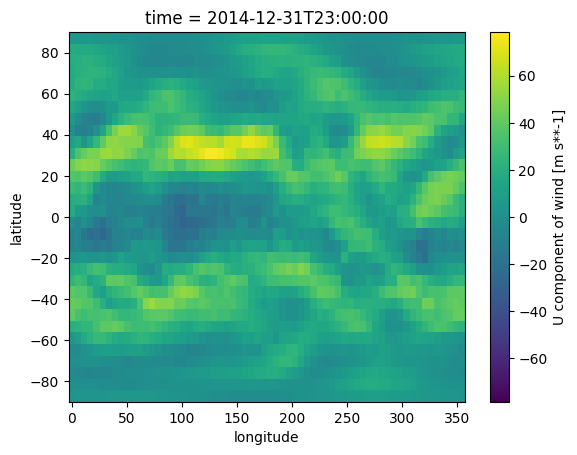

In [50]:
input_and_target_samples[0].u150.plot(cmap='viridis')

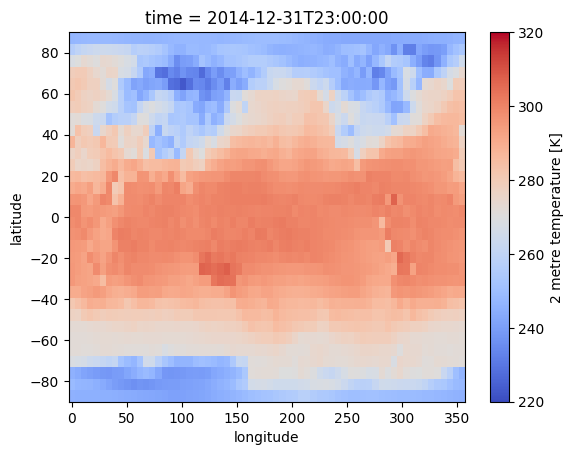

In [51]:
temperature = getattr(input_and_target_samples[0], 't2m')
temperature.plot(cmap='coolwarm', vmin=vmin, vmax=vmax)

### ACCESS Model Data

Here we see how to access a single sample of ACCESS model data

In [6]:
# We want the ACCESS data trimmed to the same bounding box as the Himawari data.
# The ACCESS data is global, but we only want the Australian region
like_himawari = petdata.transform.region.like(sample_sgi) 
access_g = petdata.archive.ACCESS( variables='sfc/mslp', datatype='an', region='g',transforms=like_himawari)

In [7]:
%%capture
sample_mslp = access_g[doi].mslp

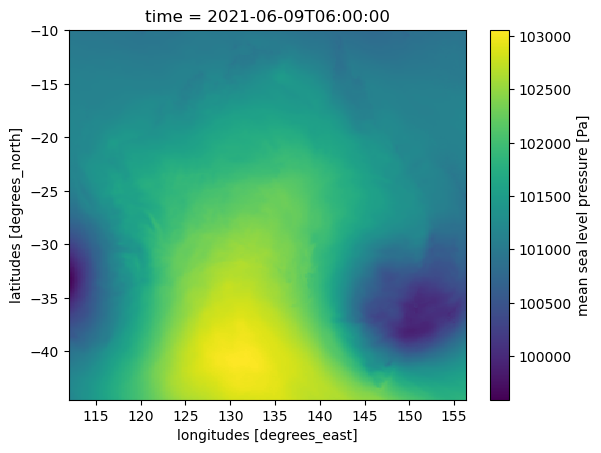

In [8]:
sample_mslp.plot()

### Radar Data

The radar data sample comes from just a single radar, and its geospatial data is not known. We can retrieve samples by date, but it's not easy to geolocate them. Let's examine some data.

In [9]:
radar = petdata.archive.RadarDemo(variables='prcp-crate')

In [10]:
radar_sample = radar[doi]
radar_sample

<xarray.Dataset> Size: 40MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (y, n2) float64 33kB -1e+03 -1.002e+03 ... -5.098e+03 -5.1e+03
    x_bounds    (x, n2) float64 39kB -2.3e+03 -2.298e+03 ... 2.598e+03 2.6e+03
    rain_rate   (y, x) float64 40MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

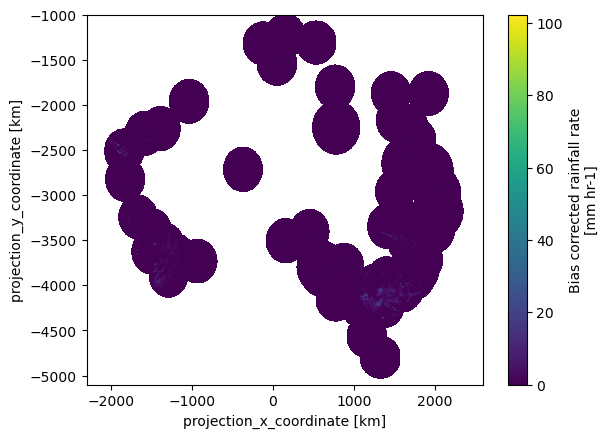

In [11]:
radar_sample.rain_rate.plot()

## Putting them together, the simple way, without "merging" them

Despite their differences, these data sources can easily be co-indexed. If all you want to do is retrieve the relevant samples by date, than can be done quickly and easily using a pipeline.

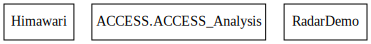

In [12]:
pipe = petpipe.Pipeline(
    (himawari, access_g, radar),
)
pipe

In [13]:
%%capture
all_sources = pipe[doi]

In [14]:
# Indexing into the pipeline by the data of interest returns a tuple, with
# the retrieved item from each data source according to that data of interest
print(type(all_sources))
print(len(all_sources))

<class 'tuple'>
3


In [15]:
all_sources[2]  # 

<xarray.Dataset> Size: 40MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (y, n2) float64 33kB -1e+03 -1.002e+03 ... -5.098e+03 -5.1e+03
    x_bounds    (x, n2) float64 39kB -2.3e+03 -2.298e+03 ... 2.598e+03 2.6e+03
    rain_rate   (y, x) float64 40MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

The coordinates of the radar data are specified as "X" and "Y". Because the radar data has X and Y, we have no way to correlate it with the latitude and longitude dimensions of the Himawari and ACCESS data.

## Merging datasets onto a common grid

(Please note! There is no reason to assume that you want the data on a common grid for machine learning. Many ML algorithms are happy with (and may prefer) unhomogenised data!)

It can be useful to try to merge data sources onto a common grid, so that they all have data at the exact same spots. For example, consider the following data sets:

```
x1=[1,  3,   6,   9, 10],   y1=[1, 9, 36, 81, 100]
x2=[1, 2, 4, 6, 8,   10],   y2=[1, 4, 36, 64, 100]
```

They both fulfil y=x^2, but with slightly different coordinates, but both ranging from 1 to 10 inclusive. The semantics of the ordinal indexing (place value) do not match the semantics of the cadinal indexing (the actual value of the coordinate). It can be really useful to line up two datasets with the same x values. When doing so, it's necessary to guess the corresponding y value in some fashion. In leiu of a clear formula, a linear interpolation of the y values is used.

Either both y1 and y2 could each be interpolated to provide values for, say x=`[1,2,3,4,5,6,7,8,9,10]`, or y1 could be interpolated to give values for the x1 coordinates.

In earth system modelling terms, the most common interpolation is between coordinate reference systems, possibly including different spatial resolutions. "x" in that case is the latitude and longitude values, and "y" would be the data values.

PyEarthTools supports a number of transformations. This notebook demonstrates the "InterpLike" transformation which will map one dataset onto the coordinates of another using linear interpolation.

The first step will be looking at merging Himawari with ACCESS, and then subsequently we will look at how to deal with the fact the radar data cannot be simply merged.

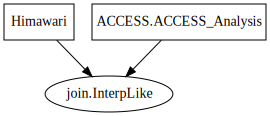

In [16]:
pipe = petpipe.Pipeline(
    (himawari, access_g),
    petpipe.operations.xarray.join.InterpLike(sample_mslp[0])
)
pipe

In [17]:
%%capture
merged_sample = pipe[doi]


In [18]:
merged_sample

<xarray.Dataset> Size: 894kB
Dimensions:                    (time: 1, latitude: 295, longitude: 252)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T06:00:00
  * latitude                   (latitude) float32 1kB -10.02 -10.14 ... -44.47
  * longitude                  (longitude) float32 1kB 112.1 112.2 ... 156.2
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 595kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
    mslp                       (time, latitude, longitude) float32 297kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:13 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

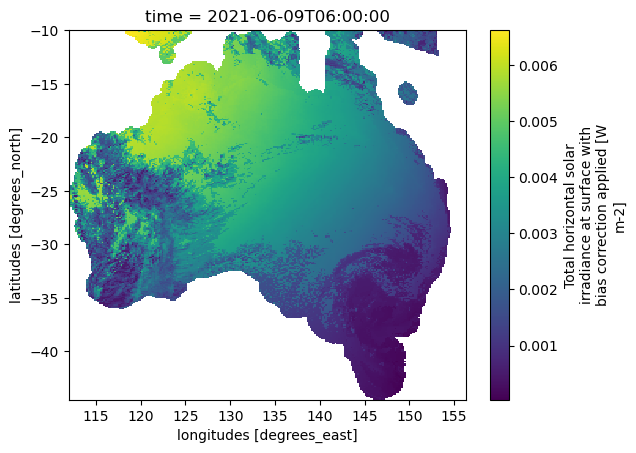

In [19]:
# If we want to, we can now operate on the samples with a common grid
(merged_sample.surface_global_irradiance / merged_sample.mslp).plot()

## Pipelines with Unmergeable Data

In this example, we will merge the Himawari and ACCESS data into a dataset which has a common coordinate reference system, but leave the radar data to be indexed separately. Each request to the pipeline according to the date of interest will return the merged data, together with the relevant unmerged data, as a tuple. The user is then able to interpret each data source as they wish.

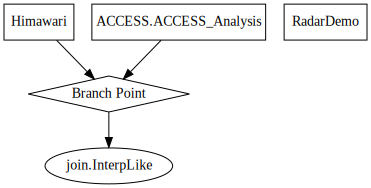

In [20]:
pipe = petpipe.Pipeline(
    (himawari, access_g),
    (petpipe.operations.xarray.join.InterpLike(sample_mslp[0]), radar)
)
pipe

In [21]:
%%capture
sample = pipe[doi]

In [22]:
sample[0]

<xarray.Dataset> Size: 894kB
Dimensions:                    (time: 1, latitude: 295, longitude: 252)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T06:00:00
  * latitude                   (latitude) float32 1kB -10.02 -10.14 ... -44.47
  * longitude                  (longitude) float32 1kB 112.1 112.2 ... 156.2
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 595kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
    mslp                       (time, latitude, longitude) float32 297kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:13 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [23]:
sample[1]

<xarray.Dataset> Size: 40MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B 2021-06-09T06:00:00
    proj        int8 1B 0
    y_bounds    (y, n2) float64 33kB -1e+03 -1.002e+03 ... -5.098e+03 -5.1e+03
    x_bounds    (x, n2) float64 39kB -2.3e+03 -2.298e+03 ... 2.598e+03 2.6e+03
    rain_rate   (y, x) float64 40MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [ 2  3  4  5  6  8  9 14 15 16 17 19 22 23 24 25 27 ...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.2.4 drs-rainfields 2021-02-02
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic